In [1]:
import sys
# Force installation of XGBoost and Scikit-Learn into your current environment
!{sys.executable} -m pip install xgboost scikit-learn pandas numpy joblib

Generating data...

🔍 Baseline Models:
Logistic Accuracy: 0.866
RandomForest Accuracy: 0.86

🚀 Training XGBoost...

📊 Final Model Performance:
Accuracy: 0.8515
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       997
           1       0.87      0.83      0.85      1003

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



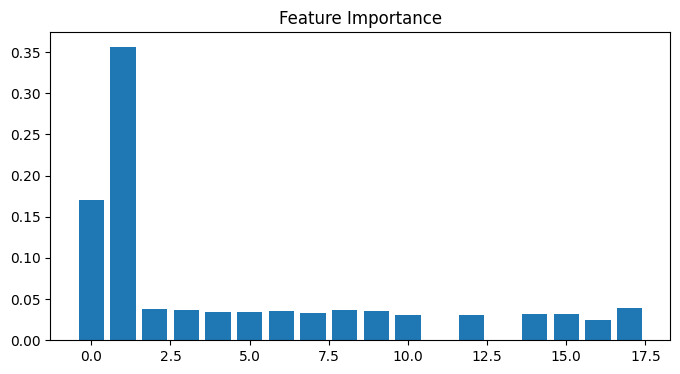


✅ Model saved successfully!


In [7]:
# --- STEP 0: IMPORTS ---
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


# --- STEP 1: PREPROCESSING ---
NUMERIC_FEATURES = ["prior_gpa","attendance_pct","quiz_avg","assign_avg","midterm",
                   "study_hours_wk","on_time_submit_pct","lms_logins_wk","forum_posts","commute_min"]

CATEGORICAL_FEATURES = ["gender","school_type","parent_edu"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, NUMERIC_FEATURES),
    ("cat", cat_pipeline, CATEGORICAL_FEATURES)
])


# --- STEP 2: DATA ---
def generate_data(n=10000):
    np.random.seed(42)
    data = {
        "prior_gpa": np.random.uniform(2.0, 4.0, n),
        "attendance_pct": np.random.uniform(40, 100, n),
        "quiz_avg": np.random.uniform(30, 100, n),
        "assign_avg": np.random.uniform(30, 100, n),
        "midterm": np.random.uniform(20, 100, n),
        "study_hours_wk": np.random.uniform(1, 25, n),
        "on_time_submit_pct": np.random.uniform(50, 100, n),
        "lms_logins_wk": np.random.uniform(0, 20, n),
        "forum_posts": np.random.randint(0, 30, n),
        "commute_min": np.random.randint(5, 120, n),
        "gender": np.random.choice(["M", "F"], n),
        "school_type": np.random.choice(["Govt", "Private"], n),
        "parent_edu": np.random.choice(["Primary", "Secondary", "UG", "PG"], n)
    }
    df = pd.DataFrame(data)
    score = (df['prior_gpa'] * 10) + (df['attendance_pct'] * 0.5)
    df['passed'] = (score + np.random.normal(0, 5, n) > 65).astype(int)
    return df


print("Generating data...")
df = generate_data()

X = df.drop(columns=["passed"])
y = df["passed"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


# --- STEP 3: BASELINE MODELS (🔥 IMPORTANT) ---
print("\n🔍 Baseline Models:")

models = {
    "Logistic": Pipeline([
        ("pre", preprocessor),
        ("clf", LogisticRegression(max_iter=200))
    ]),
    "RandomForest": Pipeline([
        ("pre", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=200))
    ])
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    print(f"{name} Accuracy:", accuracy_score(y_val, y_pred))


# --- STEP 4: XGBOOST FINAL MODEL ---
print("\n🚀 Training XGBoost...")

model_pipeline = Pipeline([
    ("pre", preprocessor),
    ("clf", XGBClassifier(n_estimators=400, max_depth=5, random_state=42))
])

calibrated_model = CalibratedClassifierCV(model_pipeline, method="isotonic", cv=3)
calibrated_model.fit(X_train, y_train)


# --- STEP 5: EVALUATION ---
y_pred = calibrated_model.predict(X_val)

print("\n📊 Final Model Performance:")
print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))


# --- STEP 6: FEATURE IMPORTANCE ---
model = calibrated_model.calibrated_classifiers_[0].estimator.named_steps['clf']
importance = model.feature_importances_

plt.figure(figsize=(8,4))
plt.bar(range(len(importance)), importance)
plt.title("Feature Importance")
plt.show()


# --- STEP 7: SAVE MODEL ---
os.makedirs("../models", exist_ok=True)
joblib.dump(calibrated_model, "../models/student_perf_calibrated.joblib")

print("\n✅ Model saved successfully!")